#  Setup

In [56]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from foraging import plotting
from foraging import utils
from matplotlib.lines import Line2D
from sklearn.model_selection import train_test_split
from scipy.stats import gamma
from tqdm import tqdm

from foraging.plotting import bp, per_block, enhanced_violinplot, titler, plot_variable_subplots
from foraging.plotting.behavior import plot_block_events, plot_pushes, plot_runlengths, plot_experiment_parameters, plot_frequencies_over_experiment, plot_experiment_overview
from foraging.utils import beliefs
from foraging.utils.data import make_df, exclusion_criteria, filter_df, display_df, get_blocks, bin_data
from foraging.utils import stats
from foraging.plotting import BOX_COLORS
from foraging.utils import  INDEX, MIN_INDEX
from functools import partial

# Filter out annoying matplotlib logs
mlogger = logging.getLogger('matplotlib')
mlogger.setLevel(logging.WARNING)

# constants
SEED = 42
RNG = np.random.default_rng(SEED)
DATA_DIR = '../data'
FIGURES_DIR = '../figures'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is given in the `Data Cleaning` notebook, as well as more details about `exclusion_criteria`.

In [11]:
df = make_df(os.path.join(DATA_DIR, 'experiments'))
df = exclusion_criteria(df)
display_df(df, ["box", "push times", "reward outcomes"])

|                                                       | box    |   push times | reward outcomes   |
|:------------------------------------------------------|:-------|-------------:|:------------------|
| ('dylan', 20211206, 2, 1, 'probability', 1, 0.1, 'M') | slow   |        3.135 | False             |
| ('dylan', 20211206, 2, 2, 'probability', 1, 0.1, 'M') | fast   |        8.465 | False             |
| ('dylan', 20211206, 2, 3, 'probability', 1, 0.1, 'M') | fast   |        9.468 | False             |
| ('dylan', 20211206, 2, 4, 'probability', 1, 0.1, 'M') | fast   |       11.667 | False             |
| ('dylan', 20211206, 2, 5, 'probability', 1, 0.1, 'M') | medium |       17.125 | False             |

In [56]:
conds = {
    'shape': 10,
    'subject': 'viktor'
}
df = filter_df(df, conds)
print(df.index.unique('kappa'))

Index([0.1, 0.04, 0.0, 0.01, 0.02, 0.03, 0.07, 0.05, 0.08], dtype='float64', name='kappa')


# Simple RL Policy
Suppose the boxes can be viewed as independent decision processes, where the decision to make is when to push. A controller that simultaneously solves this for all the boxes at a given time-- for example, if the sequence optimal pushes goes $t_2 < t_3 < t_1$, then

<Axes: title={'center': 'Distribution of push intervals when staying at box\nstay/switch = stay, kappa = 0.1'}, xlabel='prev box', ylabel='consecutive push intervals (s)'>

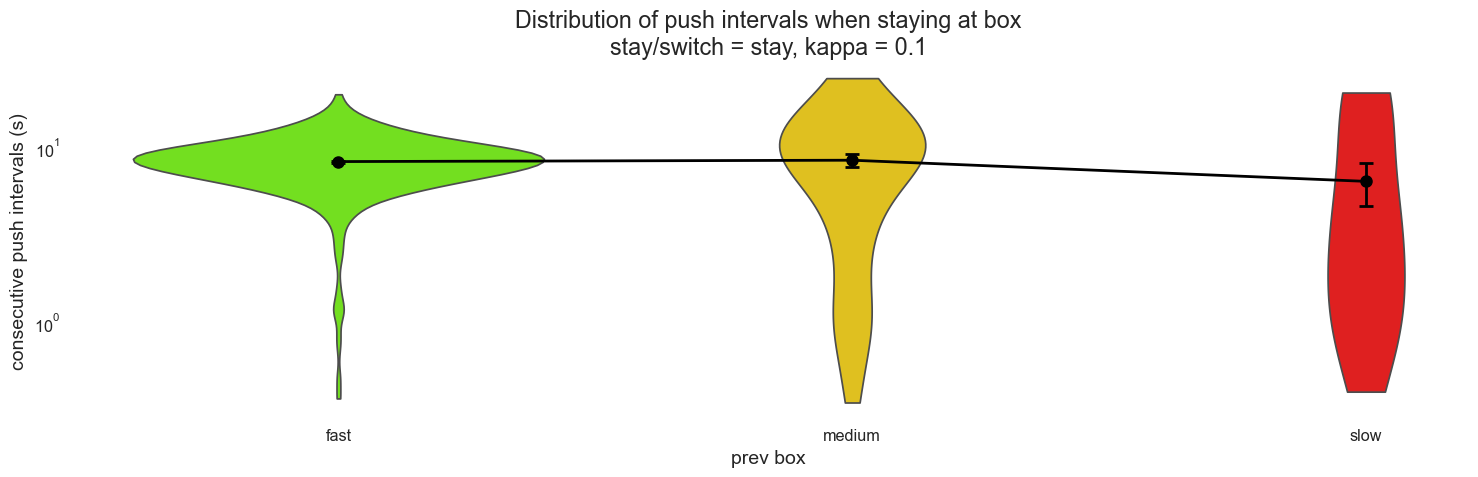

In [61]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
conds = {
    'stay/switch': 'stay',
    'kappa': 0.1
}

bp(enhanced_violinplot)(df, conds = conds, x='prev box', y='consecutive push intervals', hue = 'prev box', palette = dict(zip(BOX_LABELS, BOX_COLORS)), accumulate=True, cut=0,
                   inner=None, common_norm=True, log_scale = True, title_prefix="Distribution of push intervals when staying at box", y_unit = 's', ax=ax, legend = False)

<Axes: title={'center': 'Distribution of push intervals when staying at box\nstay/switch = switch, kappa = 0.1'}, xlabel='prev box', ylabel='consecutive push intervals (s)'>

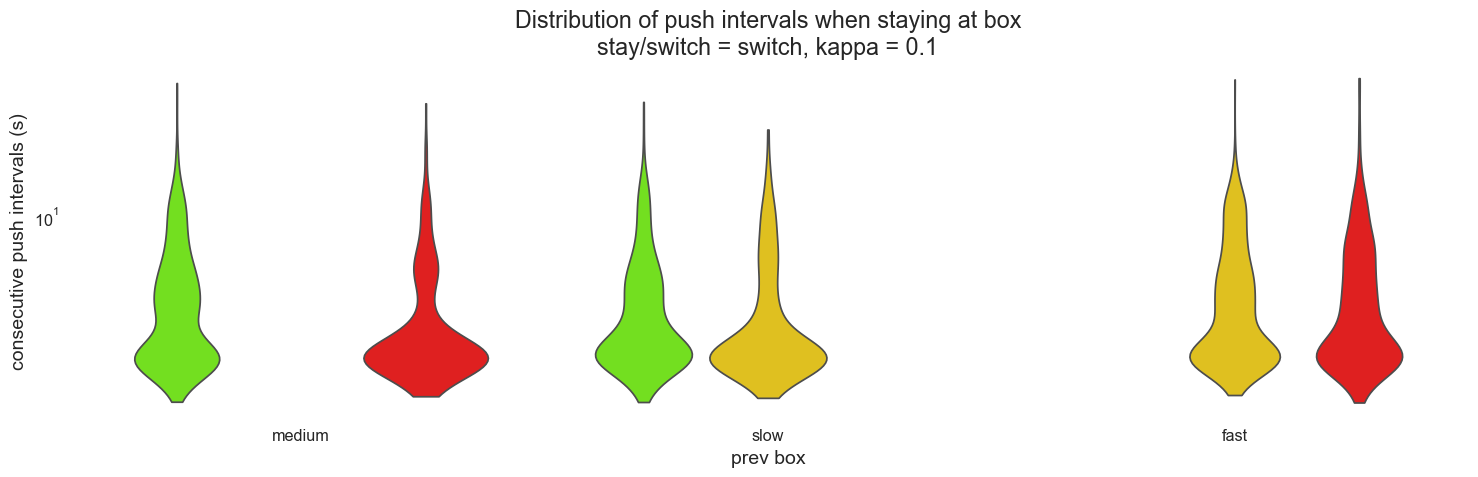

In [63]:
# Plot distribution of push intervals on log-scale
fig, ax = plt.subplots()
conds = {
    'stay/switch': 'switch',
    'kappa': 0.1
}

bp(sns.violinplot)(df, conds = conds, x='prev box', y='consecutive push intervals', hue = 'box', palette = dict(zip(BOX_LABELS, BOX_COLORS)), accumulate=True, cut=0,
                   inner=None, common_norm=True, log_scale = True, title_prefix="Distribution of push intervals when staying at box", y_unit = 's', ax=ax, legend = False)

# Hypothesis: if the data come from a Hidden Markov Model, the push intervals can be well described by an exponential distribution

In [55]:
from scipy.stats import kstest, expon
from functools import partial

# The MLE of data from an exponential distribution is 1/mean
mle_exp = 1 / df.groupby(['prev box', 'box'])['consecutive push intervals'].mean()
prev_boxes = df.dropna()['prev box'].unique()
next_boxes = df['box'].unique()
p_vals = np.zeros((len(prev_boxes), len(next_boxes)))
for i, prev_box in enumerate(prev_boxes):
    for j, next_box in enumerate(next_boxes):
        push_times = df.loc[(df['prev box'] == prev_box) & (df['box'] == next_box), 'consecutive push intervals']
        p_vals[i,j] = kstest(push_times, cdf = partial(expon.cdf, scale = mle_exp.loc[(prev_box, next_box)])).pvalue
p_vals

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 4.71888911e-233, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000]])

Single box, single decision optimal push time

Text(0, 0.5, '$Q(t) = e^{-\\gamma t}F(t)$')

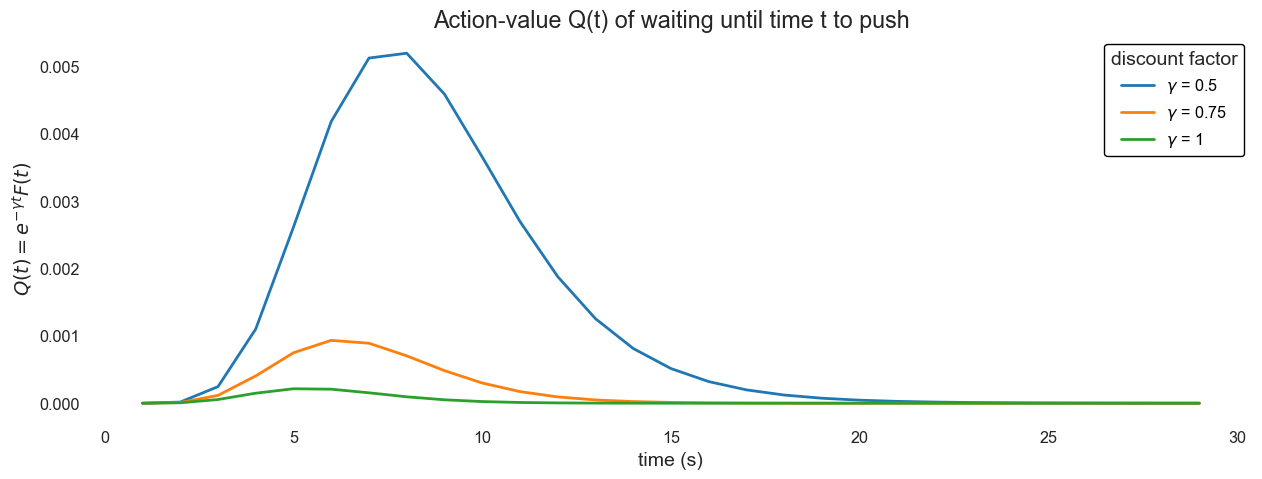

In [81]:
def q_value(discount_factor, t, schedule, alpha = 10):
    return np.exp(-discount_factor*t) * gamma.cdf(t, a = alpha, scale = schedule / alpha)

ts = np.arange(1, 30)
discounts = [0.5, 0.75, 1]
schedule = 10
for discount in discounts:
    ys = q_value(discount, ts, schedule)
    plt.plot(ts, ys, label = rf'$\gamma$ = {discount}')
plt.legend(title = 'discount factor')
plt.title(r"Action-value Q(t) of waiting until time t to push")
plt.xlabel('time (s)')
plt.ylabel(r'$Q(t) = e^{-\gamma t}F(t)$')

# Hidden Semi-Markov Model
The time between pushes are log-normal


# Simple Policy

In [40]:
N = 1000 # n steps in env
N_BOXES = 3
thresholds = np.linspace(0.1, 1, 5, endpoint = False)
# thresholds = [0.1]
box_states = np.zeros(N_BOXES)
elapsed_time = np.zeros_like(box_states)
schedules = [7, 14, 21]
average_reward_global = np.zeros(len(thresholds))
average_reward_local = np.zeros((len(thresholds), N_BOXES))
reward_rates_global = np.zeros(len(thresholds))
reward_rates_local = np.zeros((len(thresholds), N_BOXES))
discounts = np.linspace(0, 1, 5)
discounted_reward_global = np.zeros((len(discounts), len(thresholds)))
discounted_reward_local = np.zeros((len(discounts), len(thresholds), N_BOXES))
past_window_times =[[]] * N_BOXES

# Pick threshold
reward_history = [[]] * len(thresholds)
for thresh_i, thresh in enumerate(thresholds):
    push_ts = np.array([gamma.ppf(thresh, a = 10, scale = schedules[i] / 10) for i in range(N_BOXES)])

    # Init boxes
    for i in range(N_BOXES):
        box_states[i] = gamma.rvs(a = 10, scale = schedules[i] / 10)

    n_visits_by_box = [[]] * N_BOXES
    timer = np.zeros(N_BOXES)
    total_time = 0
    for i in range(1, N+1):
        pick_i = np.argmin(timer + push_ts) #todo: handle tie breaker
        pick_t = (timer + push_ts)[pick_i]
        r = 0
        if box_states[pick_i] <= pick_t:
            r = 1
        average_reward_global[thresh_i] += 1/i *(r - average_reward_global[thresh_i])
        reward_history[thresh_i].append(average_reward_global[thresh_i])
        total_time = pick_t
        timer[pick_i] = pick_t
        box_states[pick_i] = pick_t + gamma.rvs(a = 10, scale = schedules[pick_i] / 10)
        print(elapsed_time, box_states, pick_i, pick_t, thresh)


[0. 0. 0.] [12.32470836 17.23866326 25.02316459] 0 4.354913223657522 0.1
[0. 0. 0.] [16.66504398 17.23866326 25.02316459] 0 8.709826447315043 0.1
[0. 0. 0.] [16.66504398 19.87574023 25.02316459] 1 8.709826447315043 0.1
[0. 0. 0.] [21.36913545 19.87574023 25.02316459] 0 13.064739670972564 0.1
[0. 0. 0.] [21.36913545 19.87574023 24.61909298] 2 13.064739670972566 0.1
[0. 0. 0.] [24.1609789  19.87574023 24.61909298] 0 17.419652894630087 0.1
[0. 0. 0.] [24.1609789  36.8914074  24.61909298] 1 17.419652894630087 0.1
[0. 0. 0.] [30.00396294 36.8914074  24.61909298] 0 21.77456611828761 0.1
[0. 0. 0.] [30.00396294 35.40549041 24.61909298] 1 26.129479341945128 0.1
[0. 0. 0.] [32.41221352 35.40549041 24.61909298] 0 26.12947934194513 0.1
[0. 0. 0.] [32.41221352 35.40549041 46.75792021] 2 26.12947934194513 0.1
[0. 0. 0.] [40.72107496 35.40549041 46.75792021] 0 30.484392565602654 0.1
[0. 0. 0.] [45.98271212 35.40549041 46.75792021] 0 34.83930578926017 0.1
[0. 0. 0.] [45.98271212 54.64261036 46.757920

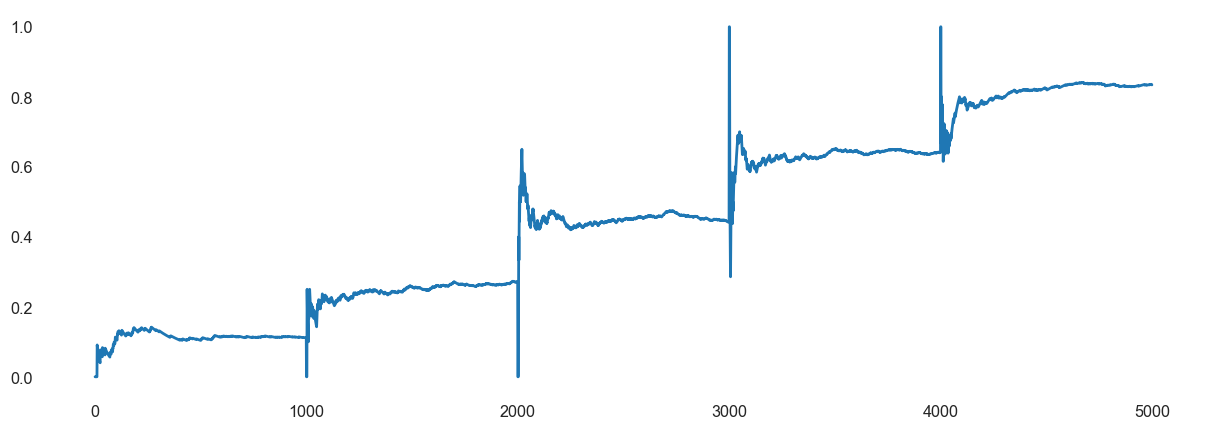

In [42]:
plt.plot(np.array(reward_history[0]).T)

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import Generator, PCG64

# --- Simulation Code ---
def simulate_agent(N=1000, N_sims = 100, seeds = None, shape_param=10.0, means=[7, 14, 21], thresholds=[0.5, 0.6, 0.7, 0.8, 0.9], discount_rates=[0.01, 0.05, 0.1]):
    if seeds is None:
        seeds = np.arange(N_sims)
    scales = [m / shape_param for m in means]
    n_boxes = len(means)
    dfs = []
    for sim in tqdm(range(N_sims)):
        gamma.random_state = Generator(PCG64(seeds[sim]))
        for threshold in thresholds:
            log = []
            boxes = []
            for i in range(n_boxes):
                reward_interval = gamma.rvs(shape_param, scale=scales[i])
                boxes.append({
                    'last_push_time': 0.0,
                    'reward_time': reward_interval,
                    'shape': shape_param,
                    'scale': scales[i],
                    'threshold': threshold
                })

            for step in range(N):
                next_push_times = []
                for i, box in enumerate(boxes):
                    t_since_last = gamma.ppf(box['threshold'], box['shape'], scale=box['scale'])
                    next_push_time = box['last_push_time'] + t_since_last
                    next_push_times.append((next_push_time, i))

                next_push_times.sort()
                soonest_time, _ = next_push_times[0]
                reward_obtained = 0
                pushed_box = []
                rts= []
                for pt, i in next_push_times:
                    if np.isclose(pt, soonest_time, atol = 0):
                        reward_obtained += soonest_time >= boxes[i]['reward_time']
                        rts.append(boxes[i]['reward_time'])
                        new_interval = gamma.rvs(boxes[i]['shape'], scale=boxes[i]['scale'])
                        boxes[i]['last_push_time'] = soonest_time
                        boxes[i]['reward_time'] = soonest_time + new_interval
                        pushed_box.append(i)

                time = soonest_time
                log.append({
                    'time': time,
                    'reward': int(reward_obtained),
                    'threshold': threshold,
                    'boxes': pushed_box,
                    'reward_times': rts,
                    'sim': sim
                })

            df_run = pd.DataFrame(log)
            df_run['cumulative_reward'] = df_run['reward'].cumsum()
            df_run['reward_rate'] = df_run['cumulative_reward'] / (df_run['time'] + 1e-8)
            for gamma_ in discount_rates:
                discounts = np.exp(-gamma_ * df_run['time'])
                discounted_reward = (df_run['reward'] * discounts).cumsum()
                df_run[f'discounted_reward_gamma_{gamma_}'] = discounted_reward
            dfs.append(df_run)
    return pd.concat(dfs)

# --- Run the simulation ---
df = simulate_agent()

100%|██████████| 100/100 [02:07<00:00,  1.28s/it]


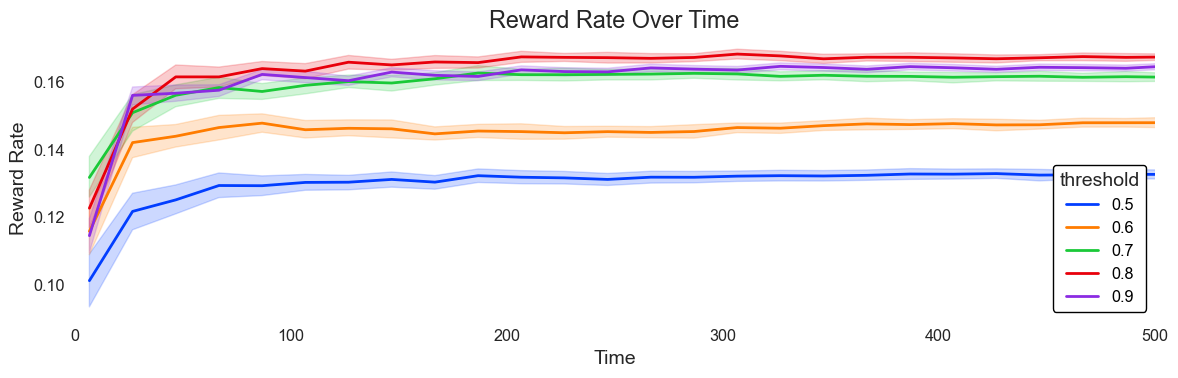

In [148]:
plt.figure(figsize=(12, 4))
df['time bins'] = bin_data(df, 'time', bin_width=20)
sns.lineplot(x='time bins', y='reward_rate', hue = 'threshold', data=df, palette = 'bright')
plt.title("Reward Rate Over Time")
plt.xlabel("Time")
plt.ylabel("Reward Rate")
# plt.grid(True)
plt.xlim([0, 500])
plt.tight_layout()
plt.show()

In [164]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma

def plot_trajectory(df, box_id=0, steps_to_plot=5, means=[7, 14, 21], shape = 10, box_colors = BOX_COLORS):
    """
    Visualize reward probability trajectory for a given box_id, accounting for multiple boxes being pushed at once.
    """
    scale = means[box_id] / shape

    fig, ax = plt.subplots(figsize=(10, 6))

    # Track last push time for the box of interest
    last_push_time = 0
    count = 0
    probs_all = []
    ts_all = []
    label_flags = [0,0]
    for _, row in df.iterrows():
        if box_id not in row['boxes']:
            continue  # skip events that don't involve this box

        push_time = row['time']
        i = row['boxes'].index(box_id)
        reward_time = row['reward_times'][i]
        rewarded = reward_time <= push_time

        # Time points for plotting the reward probability curve
        ts = np.linspace(last_push_time, push_time, 200)
        probs = gamma.cdf(ts - last_push_time, shape, scale=scale)
        probs_all.append(probs)
        ts_all.append(ts)

        # Vertical line at reward delivery
        if rewarded:
            ax.axvline(reward_time, color='red', label='Reward time (rewarded)' if label_flags[0] == 0 else None)
            label_flags[0] = 1
        else:
            ax.axvline(reward_time, color='blue', label='Reward time (not rewarded)' if label_flags[1] == 0 else None)
            label_flags[1] = 1

        # # Vertical line at push time
        # ax.axvline(push_time, color='green', linestyle='-', linewidth=2, alpha=0.7, label='Push time' if count == 0 else None)

        # Optional: show threshold line
        threshold = row['threshold']

        last_push_time = push_time
        count += 1
        if count >= steps_to_plot:
            break

    # Plot reward probability curve
    ax.plot(np.concatenate(ts_all), np.concatenate(probs_all), color=box_colors[box_id], label='Reward probability')
    ax.hlines(threshold, 0, last_push_time, color='gray', linestyle=':', alpha=0.4, label = 'threshold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Time")
    ax.set_ylabel("Reward Probability")
    ax.set_title(f"Trajectory for Box {box_id}")
    # ax.legend()
    plt.tight_layout()
    plt.show()
    return ax


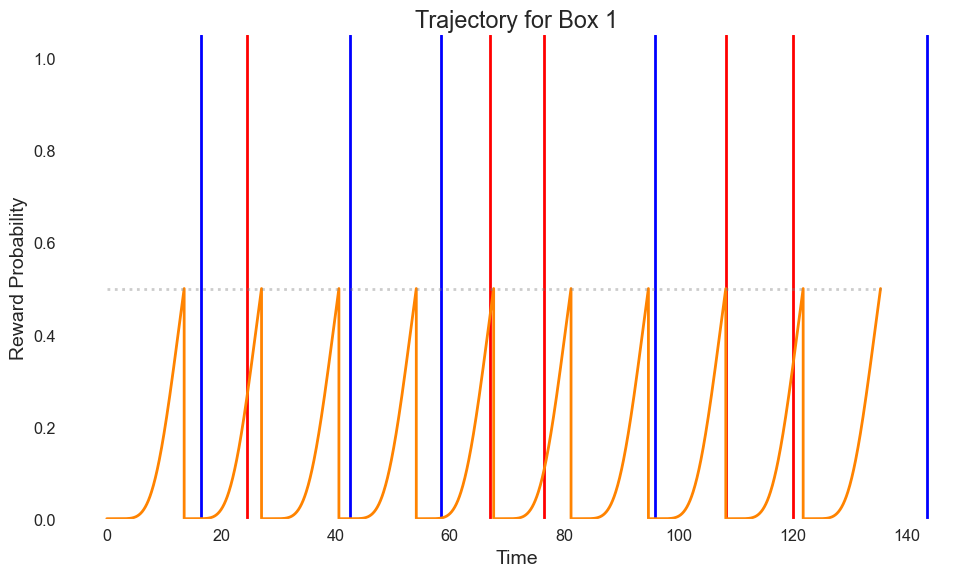

In [165]:
ax = plot_trajectory(df[(df['threshold'] == 0.5) & (df['sim'] == 0)], box_id=1, steps_to_plot=10)

In [150]:
df[(df['threshold'] == 0.5) & (df['sim'] == 0)]

,time,reward,threshold,boxes,reward_times,sim,cumulative_reward,reward_rate,discounted_reward_gamma_0.01,discounted_reward_gamma_0.05,discounted_reward_gamma_0.1,time bins
0,6.768100,0,0.5,[0],[7.044009594641757],0,0,0.000000,0.000000,0.000000,0.000000,6.767
1,13.536200,0,0.5,"[0, 1]","[16.788030940620867, 16.516729983023062]",0,0,0.000000,0.000000,0.000000,0.000000,6.767
2,20.304301,2,0.5,"[0, 2]","[18.88391646844268, 16.99954017099173]",0,2,0.098501,1.632486,0.724649,0.262558,6.767
3,27.072401,2,0.5,"[0, 1]","[23.167338129813665, 24.53380763147598]",0,4,0.147752,3.158140,1.241256,0.395999,26.768
4,33.840501,1,0.5,[0],[32.72232177104926],0,5,0.147752,3.871047,1.425402,0.429909,26.768
...,...,...,...,...,...,...,...,...,...,...,...,...
995,6741.027829,1,0.5,"[0, 1, 2]","[6744.796596888249, 6738.4875962158985, 6749.2...",0,919,0.136329,13.841361,2.029577,0.483927,6726.768
996,6747.795930,0,0.5,[0],[6749.223071420434],0,919,0.136193,13.841361,2.029577,0.483927,6746.768
997,6754.564030,1,0.5,"[0, 1]","[6752.640062184071, 6754.571824976669]",0,920,0.136204,13.841361,2.029577,0.483927,6746.768
998,6761.332130,1,0.5,"[0, 2]","[6763.379821359115, 6755.862277482718]",0,921,0.136216,13.841361,2.029577,0.483927,6746.768


## Noisy Observation

In [132]:
def compute_next_push_time(last_push, reward_time, threshold, scale, noise_sd, shape = 10):
    # Noisy internal estimate
    noisy_estimate = reward_time + np.random.normal(0, noise_sd)
    est_time = max(0, noisy_estimate) + 1 # add bias since it makes sense to push after estimated reward interval

    # Threshold-based time
    thresh_time = last_push + gamma.ppf(threshold, shape, scale = scale)
    return 1/(noise_sd**2 + 1) * est_time + (1 - 1/(noise_sd**2 + 1)) * thresh_time

def simulate_agent_noisy_obs(N=1000, N_sims = 100, seeds = None, shape_param=10.0, means=[7, 14, 21], thresholds=[0.5, 0.6, 0.7, 0.8, 0.9], discount_rates=[0.01, 0.05, 0.1], noise_sds = [0.01, 0.1, 0.5, 1]):
    if seeds is None:
        seeds = np.arange(N_sims)
    scales = [m / shape_param for m in means]
    n_boxes = len(means)
    dfs = []
    for sim in tqdm(range(N_sims)):
        gamma.random_state = Generator(PCG64(seeds[sim]))
        for noise_sd in noise_sds:
            for threshold in thresholds:
                log = []
                boxes = []
                for i in range(n_boxes):
                    reward_interval = gamma.rvs(shape_param, scale=scales[i])
                    boxes.append({
                        'last_push_time': 0.0,
                        'reward_time': reward_interval,
                        'shape': shape_param,
                        'scale': scales[i],
                        'threshold': threshold
                    })

                for step in range(N):
                    next_push_times = []
                    for i, box in enumerate(boxes):
                        next_push_time = compute_next_push_time(box['last_push_time'], box['reward_time'], box['threshold'], box['scale'], noise_sd, shape = box['shape'])
                        next_push_times.append((next_push_time, i))

                    next_push_times.sort()
                    soonest_time, _ = next_push_times[0]
                    reward_obtained = 0
                    pushed_box = []
                    rts= []
                    for pt, i in next_push_times:
                        if np.isclose(pt, soonest_time, atol = 0):
                            reward_obtained += soonest_time >= boxes[i]['reward_time']
                            rts.append(boxes[i]['reward_time'])
                            new_interval = gamma.rvs(boxes[i]['shape'], scale=boxes[i]['scale'])
                            boxes[i]['last_push_time'] = soonest_time
                            boxes[i]['reward_time'] = soonest_time + new_interval
                            pushed_box.append(i)

                    time = soonest_time
                    log.append({
                        'time': time,
                        'reward': int(reward_obtained),
                        'threshold': threshold,
                        'noise_sd': noise_sd,
                        'boxes': pushed_box,
                        'reward_times': rts,
                        'sim': sim
                    })

                df_run = pd.DataFrame(log)
                df_run['cumulative_reward'] = df_run['reward'].cumsum()
                df_run['reward_rate'] = df_run['cumulative_reward'] / (df_run['time'] + 1e-8)
                for gamma_ in discount_rates:
                    discounts = np.exp(-gamma_ * df_run['time'])
                    discounted_reward = (df_run['reward'] * discounts).cumsum()
                    df_run[f'discounted_reward_gamma_{gamma_}'] = discounted_reward
                dfs.append(df_run)
    return pd.concat(dfs)

# --- Run the simulation ---
df = simulate_agent_noisy_obs(N = 500, thresholds = [0.5, 0.8])

100%|██████████| 100/100 [01:40<00:00,  1.01s/it]


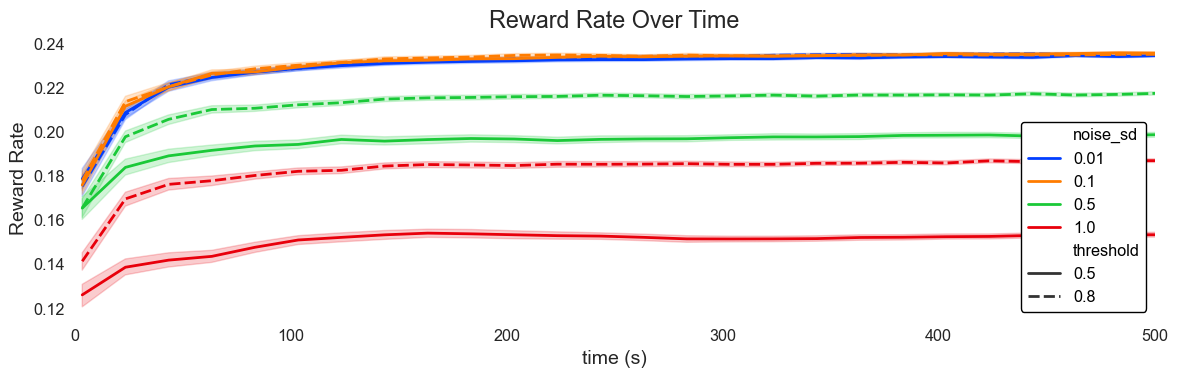

In [133]:
from foraging.utils.data import bin_data
plt.figure(figsize=(12, 4))
df['time bins'] = bin_data(df, 'time', bin_width=20)
sns.lineplot(x='time bins', y='reward_rate', hue = 'noise_sd', data=df, style = 'threshold', palette = 'bright')
plt.title("Reward Rate Over Time")
plt.xlabel("time (s)")
plt.ylabel("Reward Rate")
# plt.grid(True)
plt.xlim([0, 500])
plt.tight_layout()
plt.show()

In [138]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma

def plot_trajectory2(df, box_id=0, steps_to_plot=5, means=[7, 14, 21], shape = 10, box_colors = BOX_COLORS):
    """
    Visualize reward probability trajectory for a given box_id, accounting for multiple boxes being pushed at once.
    """
    scale = means[box_id] / shape

    fig, ax = plt.subplots(figsize=(10, 6))

    # Track last push time for the box of interest
    last_push_time = 0
    count = 0
    probs_all = []
    ts_all = []
    label_flags = [0,0]
    for _, row in df.iterrows():
        if box_id not in row['boxes']:
            continue  # skip events that don't involve this box

        push_time = row['time']
        i = row['boxes'].index(box_id)
        reward_time = row['reward_times'][i]
        rewarded = reward_time <= push_time

        # Time points for plotting the reward probability curve
        ts = np.linspace(last_push_time, push_time, 200)
        probs = gamma.cdf(ts - last_push_time, shape, scale=scale)
        probs_all.append(probs)
        ts_all.append(ts)

        # Vertical line at reward delivery
        if rewarded:
            ax.axvline(reward_time, color='green', label='Reward time (rewarded)' if label_flags[0] == 0 else None)
            label_flags[0] = 1
        else:
            ax.axvline(reward_time, color='red', label='Reward time (not rewarded)' if label_flags[1] == 0 else None)
            label_flags[1] = 1

        # # Vertical line at push time
        ax.axvline(push_time, color='black', linestyle='--', linewidth=2, alpha=0.7, label='Push time' if count == 0 else None)

        # Optional: show threshold line
        threshold = row['threshold']

        last_push_time = push_time
        count += 1
        if count >= steps_to_plot:
            break

    # Plot reward probability curve
    ax.plot(np.concatenate(ts_all), np.concatenate(probs_all), color=box_colors[box_id], label='Reward probability')
    ax.hlines(threshold, 0, last_push_time, color='gray', linestyle=':', alpha=0.4, label = 'threshold')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Time")
    ax.set_ylabel("Reward Probability")
    ax.set_title(f"Trajectory for Box {box_id}")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return ax


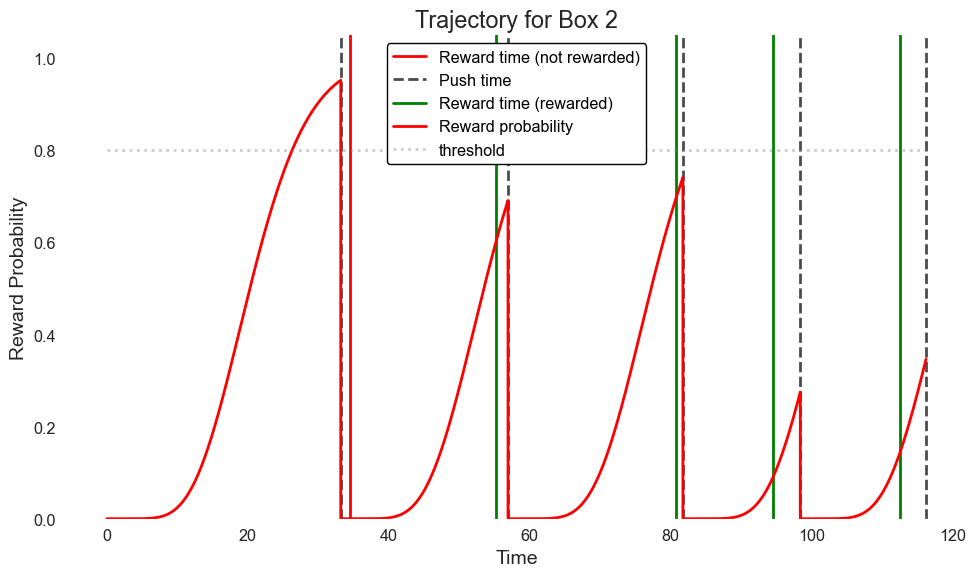

In [142]:
ax = plot_trajectory2(df[(df['threshold'] == 0.8) & (df['noise_sd'] == 0.5) & (df['sim'] == 0)], box_id=2, steps_to_plot=5)

In [145]:
# todo: sim where fast box is pushed according to threshold of 0.8, but other two boxes the threshold is allowed to vary
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.random import Generator, PCG64

# --- Simulation Code ---
def simulate_agent_vary_threshold(N=1000, N_sims = 100, seeds = None, shape_param=10.0, means=[7, 14, 21], thresholds=[(0.5, 0.4), (0.7, 0.6)], discount_rates=[0.01, 0.05, 0.1]):
    if seeds is None:
        seeds = np.arange(N_sims)
    scales = [m / shape_param for m in means]
    n_boxes = len(means)
    dfs = []
    for sim in tqdm(range(N_sims)):
        gamma.random_state = Generator(PCG64(seeds[sim]))
        for threshold in thresholds:
            log = []
            boxes = []
            for i in range(n_boxes):
                reward_interval = gamma.rvs(shape_param, scale=scales[i])
                if i == 0:
                    boxes.append({
                        'last_push_time': 0.0,
                        'reward_time': reward_interval,
                        'shape': shape_param,
                        'scale': scales[i],
                        'threshold': 0.8
                    })
                else:
                    boxes.append({
                        'last_push_time': 0.0,
                        'reward_time': reward_interval,
                        'shape': shape_param,
                        'scale': scales[i],
                        'threshold': threshold[i-1]
                    })

            for step in range(N):
                next_push_times = []
                for i, box in enumerate(boxes):
                    t_since_last = gamma.ppf(box['threshold'], box['shape'], scale=box['scale'])
                    next_push_time = box['last_push_time'] + t_since_last
                    next_push_times.append((next_push_time, i))

                next_push_times.sort()
                soonest_time, _ = next_push_times[0]
                reward_obtained = 0
                pushed_box = []
                rts= []
                for pt, i in next_push_times:
                    if np.isclose(pt, soonest_time, atol = 0):
                        reward_obtained += soonest_time >= boxes[i]['reward_time']
                        rts.append(boxes[i]['reward_time'])
                        new_interval = gamma.rvs(boxes[i]['shape'], scale=boxes[i]['scale'])
                        boxes[i]['last_push_time'] = soonest_time
                        boxes[i]['reward_time'] = soonest_time + new_interval
                        pushed_box.append(i)

                time = soonest_time
                log.append({
                    'time': time,
                    'reward': int(reward_obtained),
                    'threshold': threshold,
                    'boxes': pushed_box,
                    'reward_times': rts,
                    'sim': sim
                })

            df_run = pd.DataFrame(log)
            df_run['cumulative_reward'] = df_run['reward'].cumsum()
            df_run['reward_rate'] = df_run['cumulative_reward'] / (df_run['time'] + 1e-8)
            for gamma_ in discount_rates:
                discounts = np.exp(-gamma_ * df_run['time'])
                discounted_reward = (df_run['reward'] * discounts).cumsum()
                df_run[f'discounted_reward_gamma_{gamma_}'] = discounted_reward
            dfs.append(df_run)
    return pd.concat(dfs)

# --- Run the simulation ---
df = simulate_agent_vary_threshold()

100%|██████████| 100/100 [00:51<00:00,  1.94it/s]


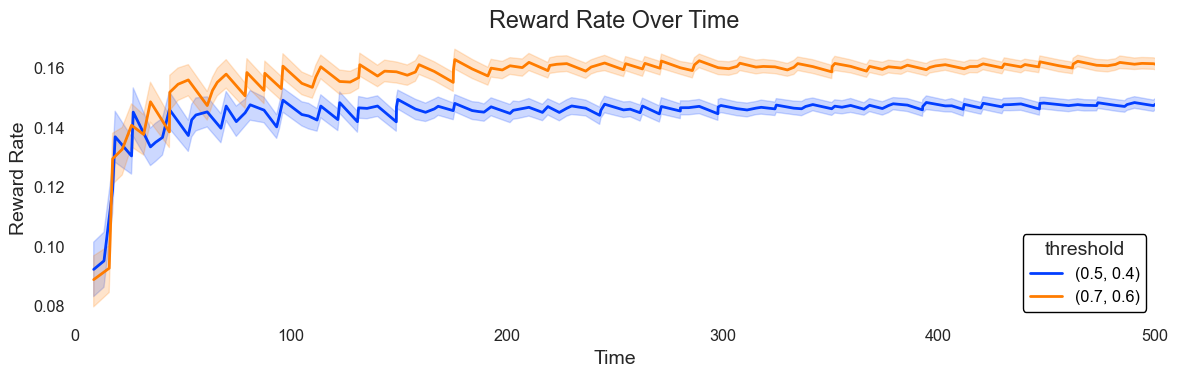

In [146]:
plt.figure(figsize=(12, 4))
sns.lineplot(x='time', y='reward_rate', hue = 'threshold', data=df, palette = 'bright')
plt.title("Reward Rate Over Time")
plt.xlabel("Time")
plt.ylabel("Reward Rate")
# plt.grid(True)
plt.xlim([0, 500])
plt.tight_layout()
plt.show()